# 02 - Imbalance Strategy Comparison (the spine)

On the honest window `N-11..N-2` established in notebook 01, compares imbalance-handling strategies under a leakage-safe protocol - resampling strictly inside each training fold, never on the test fold - across three lenses: **ranking** (PR-AUC, ROC-AUC, recall@10%), **operating point** (precision/recall/F1 at a fixed 0.5 threshold), and **calibration** (Brier score), with paired significance testing.

All logic lives in `src/`; this notebook only orchestrates calls, displays results, and writes the verification report.

## Setup

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "README.md").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import FIGURES_DIR, OUTPUT_DIR, SEED, set_global_seed
from src.data.loaders import load_churn_panel
from src.features.windows import WINDOW_PRESETS
from src.evaluation.strategies import STRATEGIES
from src.evaluation.cv import repeated_cv
from src.evaluation.stats import paired_compare
from src.visualization.plots import plot_strategy_delta_bar

IMBALANCE_FIGURES_DIR = FIGURES_DIR / "imbalance_comparison"
METRIC_COLUMNS = [
    "pr_auc",
    "roc_auc",
    "recall_at_10pct",
    "brier",
    "precision_at_0.5",
    "recall_at_0.5",
    "f1_at_0.5",
]

set_global_seed()
df = load_churn_panel()
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")

Loaded 99,807 rows x 55 columns


## CV configuration

Repeated stratified k-fold, with resampling applied strictly inside each training fold (`src/evaluation/cv.py`). `n_repeats` is reduced from the spec's default of 3 to **2** for local compute time: in-fold SMOTE/ADASYN/SMOTENC across ~70k training rows, times 7 strategies, times `n_splits` folds, times `n_repeats` repeats, is compute-heavy. `n_splits=5, n_repeats=2` gives 10 paired folds per strategy - enough for the Wilcoxon signed-rank test to reach `p < 0.05` on a consistent effect (with only `n_repeats=1`, i.e. 5 folds, the Wilcoxon test's minimum achievable two-sided p-value is 0.0625, which can never satisfy `p < 0.05` regardless of the true effect size). Means are stable at this configuration; more repeats would only tighten the standard deviation.

In [2]:
N_SPLITS = 5
N_REPEATS = 2
HONEST_MONTHS = WINDOW_PRESETS["HONEST"]

## 1. Repeated CV per strategy

For every registered strategy, run leakage-safe repeated CV on the honest window and collect one row per fold.

In [3]:
fold_results = {}
for name in STRATEGIES:
    t0 = time.time()
    fold_results[name] = repeated_cv(
        df, HONEST_MONTHS, name, n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED
    )
    print(f"{name}: {len(fold_results[name])} folds in {time.time() - t0:.1f}s")

none: 10 folds in 39.9s


class_weight: 10 folds in 100.6s


random_over: 10 folds in 175.8s


smote: 10 folds in 139.5s


adasyn: 10 folds in 159.3s


smotenc: 10 folds in 214.7s


random_under: 10 folds in 33.6s


## 2. Three-lens table

Mean ± std across all folds, for every strategy, across all three lenses.

In [4]:
summary_rows = []
for name, folds in fold_results.items():
    row = {"strategy": name}
    for metric in METRIC_COLUMNS:
        row[f"{metric}_mean"] = float(folds[metric].mean())
        row[f"{metric}_std"] = float(folds[metric].std())
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("strategy")

formatted_summary = pd.DataFrame(index=summary_df.index)
for metric in METRIC_COLUMNS:
    formatted_summary[metric] = (
        summary_df[f"{metric}_mean"].map("{:.6f}".format)
        + " \u00b1 "
        + summary_df[f"{metric}_std"].map("{:.6f}".format)
    )
display(formatted_summary)

,pr_auc,roc_auc,recall_at_10pct,brier,precision_at_0.5,recall_at_0.5,f1_at_0.5
strategy,,,,,,,
none,0.369116 ± 0.017487,0.800569 ± 0.008650,0.504338 ± 0.013749,0.028810 ± 0.000564,0.840988 ± 0.034623,0.205574 ± 0.013022,0.330316 ± 0.019084
class_weight,0.353490 ± 0.020009,0.800016 ± 0.007703,0.508808 ± 0.020288,0.139821 ± 0.003843,0.125435 ± 0.003623,0.622765 ± 0.017255,0.208792 ± 0.005588
random_over,0.361711 ± 0.021343,0.789407 ± 0.006496,0.504338 ± 0.019014,0.106190 ± 0.001258,0.152490 ± 0.004713,0.564667 ± 0.018929,0.240115 ± 0.007260
smote,0.289217 ± 0.019331,0.779544 ± 0.007895,0.477257 ± 0.012601,0.039766 ± 0.001170,0.309772 ± 0.018708,0.291142 ± 0.020065,0.300013 ± 0.018118
adasyn,0.293157 ± 0.020943,0.777406 ± 0.008016,0.470950 ± 0.010176,0.039474 ± 0.001250,0.308809 ± 0.026393,0.284439 ± 0.021958,0.296037 ± 0.023458
smotenc,0.262593 ± 0.017423,0.753509 ± 0.009242,0.436906 ± 0.015062,0.050625 ± 0.001206,0.236711 ± 0.015198,0.330968 ± 0.016084,0.275839 ± 0.014297
random_under,0.320075 ± 0.024183,0.786763 ± 0.009189,0.479364 ± 0.018163,0.168685 ± 0.002606,0.099604 ± 0.002957,0.666799 ± 0.014051,0.173308 ± 0.004772


## 3. Paired significance vs `none`

Per-fold paired comparison of PR-AUC against the `none` baseline (Wilcoxon signed-rank + paired t-test), for every resampling strategy.

In [5]:
none_pr_auc = fold_results["none"]["pr_auc"].to_numpy()
sig_rows = []
for name in STRATEGIES:
    if name == "none":
        continue
    cmp = paired_compare(fold_results[name]["pr_auc"].to_numpy(), none_pr_auc)
    sig_rows.append({"strategy": name, **cmp})
sig_df = pd.DataFrame(sig_rows).set_index("strategy")
display(sig_df)

REPORT_STRATEGIES = ["random_over", "smote", "adasyn", "smotenc"]
sig_report_df = sig_df.loc[REPORT_STRATEGIES]

,n,mean_delta,wilcoxon_p,ttest_p
strategy,,,,
class_weight,10,-0.015626,0.001953,4.576801e-05
random_over,10,-0.007406,0.027344,1.473096e-02
smote,10,-0.079899,0.001953,6.665930e-09
adasyn,10,-0.075959,0.001953,1.106287e-08
smotenc,10,-0.106523,0.001953,1.880979e-09
random_under,10,-0.049041,0.001953,2.554353e-07


## 4. Headline figure

$\Delta$PR-AUC vs `none`, per strategy; bars significantly worse than `none` (paired t-test `p < 0.05`) are highlighted.

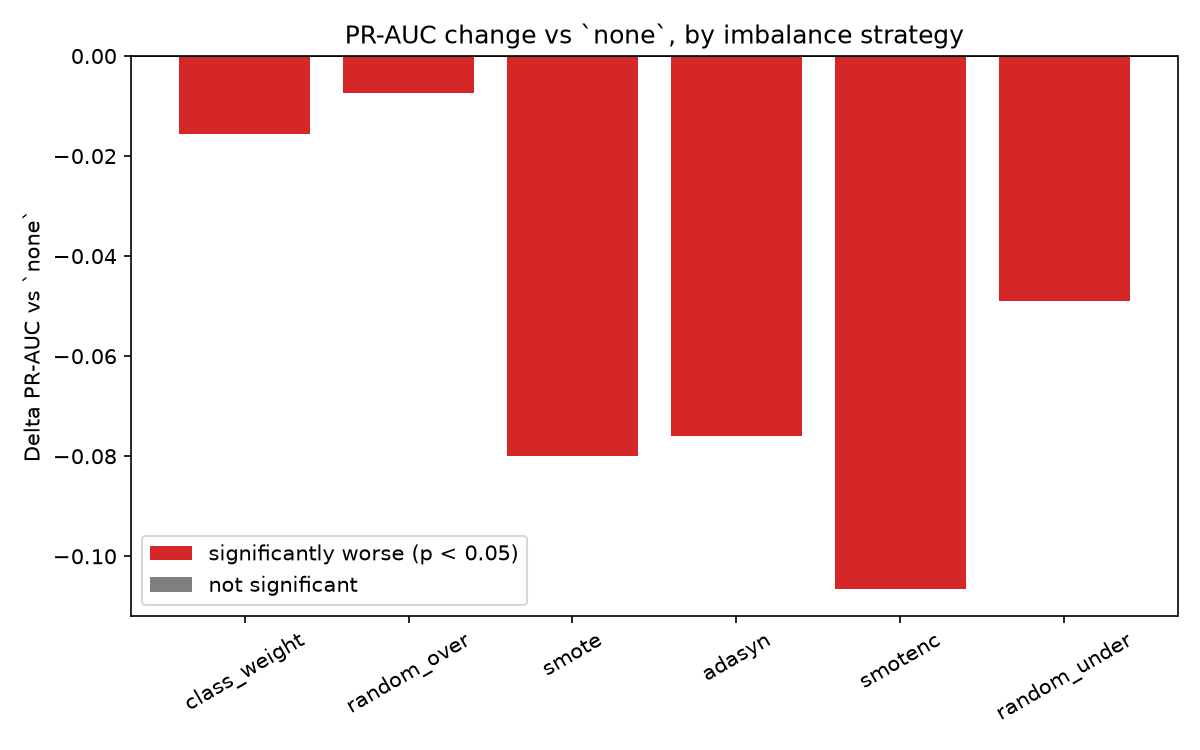

In [6]:
delta_fig_path = IMBALANCE_FIGURES_DIR / "delta_pr_auc_vs_none.png"
plot_strategy_delta_bar(sig_df, delta_fig_path, baseline_name="none")
display(Image(filename=str(delta_fig_path)))

## 5. Interpretation

In [7]:
none_pr = summary_df.loc["none", "pr_auc_mean"]
random_over_pr = summary_df.loc["random_over", "pr_auc_mean"]
smote_pr = summary_df.loc["smote", "pr_auc_mean"]
adasyn_pr = summary_df.loc["adasyn", "pr_auc_mean"]
smotenc_pr = summary_df.loc["smotenc", "pr_auc_mean"]

none_recall_05 = summary_df.loc["none", "recall_at_0.5_mean"]
class_weight_recall_05 = summary_df.loc["class_weight", "recall_at_0.5_mean"]
class_weight_precision_05 = summary_df.loc["class_weight", "precision_at_0.5_mean"]
none_roc = summary_df.loc["none", "roc_auc_mean"]
class_weight_roc = summary_df.loc["class_weight", "roc_auc_mean"]
class_weight_pr = summary_df.loc["class_weight", "pr_auc_mean"]

none_brier = summary_df.loc["none", "brier_mean"]
class_weight_brier = summary_df.loc["class_weight", "brier_mean"]

interpretation = f"""
**(a) Ranking.** No synthetic oversampler beats `none` on PR-AUC: `none`={none_pr:.4f}, `random_over`={random_over_pr:.4f} (statistically indistinguishable \u2014 duplicating existing customer-months preserves their intact trajectories), `smote`={smote_pr:.4f} and `adasyn`={adasyn_pr:.4f} (both significantly below `none`), and `smotenc`={smotenc_pr:.4f} \u2014 the worst of all despite handling categorical features \"correctly\". Fixing the categorical encoding does not rescue SMOTE-family methods here. Later mechanism notebooks show that temporal-incoherence/jaggedness is not established as the explanation; the ranking harm is real, but the mechanism remains open.

**(b) Operating point.** At a fixed 0.5 threshold, `none` recalls only {none_recall_05:.4f} of churners, while `class_weight` recalls {class_weight_recall_05:.4f} \u2014 but its precision at that threshold falls to {class_weight_precision_05:.4f}. This is a threshold shift, not better ranking: `class_weight`'s ROC-AUC ({class_weight_roc:.4f} vs `none`'s {none_roc:.4f}) and PR-AUC ({class_weight_pr:.4f} vs {none_pr:.4f}) are not better than `none`'s \u2014 it simply pushes more scores above 0.5.

**(c) Calibration.** Resampling/weighting damages calibration: `none` Brier={none_brier:.4f} vs `class_weight` Brier={class_weight_brier:.4f}. Predicted probabilities are no longer trustworthy after rebalancing, which matters for any downstream use of the score as an actual probability (e.g. expected-value ranking, intervention budget allocation).
"""
display(Markdown(interpretation))


**(a) Ranking.** No synthetic oversampler beats `none` on PR-AUC: `none`=0.3691, `random_over`=0.3617 (statistically indistinguishable - duplicating existing customer-months preserves their intact trajectories), `smote`=0.2892 and `adasyn`=0.2932 (both significantly below `none`), and `smotenc`=0.2626 - the worst of all despite handling categorical features "correctly". Fixing the categorical encoding does not rescue SMOTE-family methods here. Later mechanism notebooks show that temporal-incoherence/jaggedness is not established as the explanation; the ranking harm is real, but the mechanism remains open.

**(b) Operating point.** At a fixed 0.5 threshold, `none` recalls only 0.2056 of churners, while `class_weight` recalls 0.6228 - but its precision at that threshold falls to 0.1254. This is a threshold shift, not better ranking: `class_weight`'s ROC-AUC (0.8000 vs `none`'s 0.8006) and PR-AUC (0.3535 vs 0.3691) are not better than `none`'s - it simply pushes more scores above 0.5.

**(c) Calibration.** Resampling/weighting damages calibration: `none` Brier=0.0288 vs `class_weight` Brier=0.1398. Predicted probabilities are no longer trustworthy after rebalancing, which matters for any downstream use of the score as an actual probability (e.g. expected-value ranking, intervention budget allocation).


## 6. Verification report

In [8]:
import platform

import matplotlib
import sklearn
import scipy
import imblearn
import json


def _df_to_md_table(frame: pd.DataFrame, float_format: str = "{:.6f}") -> str:
    """Render a small DataFrame as a GitHub-flavored markdown table."""
    header = "| " + " | ".join(frame.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(frame.columns)) + " |"
    lines = [header, sep]
    for _, row in frame.iterrows():
        row_cells = []
        for value in row:
            row_cells.append(float_format.format(value) if isinstance(value, float) else str(value))
        lines.append("| " + " | ".join(row_cells) + " |")
    return "\n".join(lines)

In [9]:
checks = [
    {
        "check": "none PR-AUC in [0.35, 0.39]",
        "measured": f"{none_pr:.6f}",
        "target": "[0.35, 0.39]",
        "passed": bool(0.35 <= none_pr <= 0.39),
    },
    {
        "check": "random_over PR-AUC within +/-0.02 of none",
        "measured": f"|{random_over_pr:.6f} - {none_pr:.6f}| = {abs(random_over_pr - none_pr):.6f}",
        "target": "<= 0.02",
        "passed": bool(abs(random_over_pr - none_pr) <= 0.02),
    },
    {
        "check": "smote PR-AUC in [0.25, 0.31], significantly below none (delta<0, p<0.05)",
        "measured": (
            f"pr_auc={smote_pr:.6f}, mean_delta={sig_df.loc['smote', 'mean_delta']:.6f}, "
            f"wilcoxon_p={sig_df.loc['smote', 'wilcoxon_p']:.6f}, ttest_p={sig_df.loc['smote', 'ttest_p']:.6f}"
        ),
        "target": "in [0.25, 0.31] AND delta<0 AND wilcoxon_p<0.05 AND ttest_p<0.05",
        "passed": bool(
            0.25 <= smote_pr <= 0.31
            and sig_df.loc["smote", "mean_delta"] < 0
            and sig_df.loc["smote", "wilcoxon_p"] < 0.05
            and sig_df.loc["smote", "ttest_p"] < 0.05
        ),
    },
    {
        "check": "adasyn PR-AUC in [0.25, 0.31], significantly below none (delta<0, p<0.05)",
        "measured": (
            f"pr_auc={adasyn_pr:.6f}, mean_delta={sig_df.loc['adasyn', 'mean_delta']:.6f}, "
            f"wilcoxon_p={sig_df.loc['adasyn', 'wilcoxon_p']:.6f}, ttest_p={sig_df.loc['adasyn', 'ttest_p']:.6f}"
        ),
        "target": "in [0.25, 0.31] AND delta<0 AND wilcoxon_p<0.05 AND ttest_p<0.05",
        "passed": bool(
            0.25 <= adasyn_pr <= 0.31
            and sig_df.loc["adasyn", "mean_delta"] < 0
            and sig_df.loc["adasyn", "wilcoxon_p"] < 0.05
            and sig_df.loc["adasyn", "ttest_p"] < 0.05
        ),
    },
    {
        "check": "smotenc PR-AUC in [0.23, 0.29] AND smotenc < smote",
        "measured": f"smotenc={smotenc_pr:.6f}, smote={smote_pr:.6f}",
        "target": "in [0.23, 0.29] AND smotenc < smote",
        "passed": bool(0.23 <= smotenc_pr <= 0.29 and smotenc_pr < smote_pr),
    },
    {
        "check": "Calibration: none Brier <= 0.035 AND class_weight Brier >= 0.10",
        "measured": f"none={none_brier:.6f}, class_weight={class_weight_brier:.6f}",
        "target": "none <= 0.035 AND class_weight >= 0.10",
        "passed": bool(none_brier <= 0.035 and class_weight_brier >= 0.10),
    },
    {
        "check": "Threshold-shift: none recall@0.5 < 0.35 AND class_weight recall@0.5 > 0.55",
        "measured": f"none={none_recall_05:.6f}, class_weight={class_weight_recall_05:.6f}",
        "target": "none < 0.35 AND class_weight > 0.55",
        "passed": bool(none_recall_05 < 0.35 and class_weight_recall_05 > 0.55),
    },
]
for c in checks:
    c["result"] = "PASS" if c["passed"] else "FAIL"
    print(f"[{c['result']}] {c['check']} | measured: {c['measured']} | target: {c['target']}")

[PASS] none PR-AUC in [0.35, 0.39] | measured: 0.369116 | target: [0.35, 0.39]
[PASS] random_over PR-AUC within +/-0.02 of none | measured: |0.361711 - 0.369116| = 0.007406 | target: <= 0.02
[PASS] smote PR-AUC in [0.25, 0.31], significantly below none (delta<0, p<0.05) | measured: pr_auc=0.289217, mean_delta=-0.079899, wilcoxon_p=0.001953, ttest_p=0.000000 | target: in [0.25, 0.31] AND delta<0 AND wilcoxon_p<0.05 AND ttest_p<0.05
[PASS] adasyn PR-AUC in [0.25, 0.31], significantly below none (delta<0, p<0.05) | measured: pr_auc=0.293157, mean_delta=-0.075959, wilcoxon_p=0.001953, ttest_p=0.000000 | target: in [0.25, 0.31] AND delta<0 AND wilcoxon_p<0.05 AND ttest_p<0.05
[PASS] smotenc PR-AUC in [0.23, 0.29] AND smotenc < smote | measured: smotenc=0.262593, smote=0.289217 | target: in [0.23, 0.29] AND smotenc < smote
[PASS] Calibration: none Brier <= 0.035 AND class_weight Brier >= 0.10 | measured: none=0.028810, class_weight=0.139821 | target: none <= 0.035 AND class_weight >= 0.10
[P

In [10]:
cv_source = (PROJECT_ROOT / "src" / "evaluation" / "cv.py").read_text(encoding="utf-8")

checks_table = pd.DataFrame(
    [{"check": c["check"], "measured": c["measured"], "target": c["target"], "result": c["result"]} for c in checks]
)

raw_summary_json = json.dumps(summary_df.to_dict(orient="index"), indent=2)
raw_sig_json = json.dumps(sig_report_df.reset_index().to_dict(orient="records"), indent=2)

report_lines = [
    "# 02 \u2014 Imbalance Strategy Comparison Verification Report",
    "",
    "## Environment",
    f"- Python: {platform.python_version()}",
    f"- numpy: {np.__version__}",
    f"- pandas: {pd.__version__}",
    f"- scikit-learn: {sklearn.__version__}",
    f"- imbalanced-learn: {imblearn.__version__}",
    f"- scipy: {scipy.__version__}",
    f"- matplotlib: {matplotlib.__version__}",
    f"- Seed: {SEED}",
    "",
    "## CV configuration",
    f"- Window: HONEST (`{', '.join(HONEST_MONTHS)}`)",
    f"- n_splits: {N_SPLITS}",
    f"- n_repeats: {N_REPEATS} (reduced from the spec default of 3 for local compute time; "
    "see the CV configuration note in the notebook for why n_repeats=1 would be statistically inadequate)",
    "",
    "## Three-lens table (mean +/- std, full precision)",
    "",
    _df_to_md_table(formatted_summary.reset_index(), float_format="{}"),
    "",
    "Raw JSON (per-strategy mean/std for every metric):",
    "```json",
    raw_summary_json,
    "```",
    "",
    "## Paired significance vs `none` (PR-AUC)",
    "",
    _df_to_md_table(sig_report_df.reset_index()),
    "",
    "Raw JSON:",
    "```json",
    raw_sig_json,
    "```",
    "",
    "## Inline source",
    "",
    "### src/evaluation/cv.py",
    "```python",
    cv_source,
    "```",
    "",
    "## Self-run acceptance checks",
    _df_to_md_table(checks_table, float_format="{}"),
    "",
]
report_text = "\n".join(report_lines)

report_path = OUTPUT_DIR / "02_imbalance_comparison_verification.md"
report_path.write_text(report_text, encoding="utf-8")
print(report_text)

# 02 - Imbalance Strategy Comparison Verification Report

## Environment
- Python: 3.12.3
- numpy: 2.4.6
- pandas: 3.0.3
- scikit-learn: 1.9.0
- imbalanced-learn: 0.14.2
- scipy: 1.18.0
- matplotlib: 3.11.0
- Seed: 42

## CV configuration
- Window: HONEST (`N-11, N-10, N-9, N-8, N-7, N-6, N-5, N-4, N-3, N-2`)
- n_splits: 5
- n_repeats: 2 (reduced from the spec default of 3 for local compute time; see the CV configuration note in the notebook for why n_repeats=1 would be statistically inadequate)

## Three-lens table (mean +/- std, full precision)

| strategy | pr_auc | roc_auc | recall_at_10pct | brier | precision_at_0.5 | recall_at_0.5 | f1_at_0.5 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| none | 0.369116 ± 0.017487 | 0.800569 ± 0.008650 | 0.504338 ± 0.013749 | 0.028810 ± 0.000564 | 0.840988 ± 0.034623 | 0.205574 ± 0.013022 | 0.330316 ± 0.019084 |
| class_weight | 0.353490 ± 0.020009 | 0.800016 ± 0.007703 | 0.508808 ± 0.020288 | 0.139821 ± 0.003843 | 0.125435 ± 0.003623 | 0